# 빅데이터 처리와 시각화 10장 - 시각화 도구의 활용 Ⅱ: Seaborn
## Figure-level vs Axes-level 함수

이번 장에서는 Matplotlib 위에 구축된 **고수준 시각화 라이브러리 Seaborn**을 학습.

<div class="alert alert-block alert-info">
<b>💡 이번 장에서 배우는 것</b><br>
9장에서 Matplotlib으로 직접 그렸던 그래프를 Seaborn으로 훨씬 간결하게 그리는 방법, 그리고 Seaborn의 핵심 설계 철학인 <b>Figure-level / Axes-level 함수</b>의 차이를 이해하고 올바르게 선택하는 법을 배운다.
</div>

| 섹션 | 주제 | 
| :--- | :--- |
| 1 | Seaborn 소개 & 환경 설정 | 
| 2 | 데이터 준비 |
| 3 | **Axes-level 함수** — 분포·관계·범주형 |
| 4 | **Figure-level 함수** — relplot·displot·catplot |
| 5 | Figure-level vs Axes-level **핵심 비교** |
| 6 | FacetGrid 심화 — col/row 패널 분할 |
| 7 | 종합 실습 & 정리 |

In [2]:
import platform
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 운영체제(OS)별 한글 폰트 이름 결정
if platform.system() == "Darwin":  # Mac
    font_family = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    font_family = "Malgun Gothic"
else:  # Linux / Colab 등
    font_family = "NanumGothic"

# Matplotlib과 Seaborn에 폰트 및 마이너스 기호 설정 통합 적용
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

# Seaborn의 폰트 캐시도 함께 업데이트
sns.set_context("notebook", rc={"font.family": font_family})

# 버전 확인
print(f"Seaborn 버전: {sns.__version__}")
print(f"Matplotlib 버전: {mpl.__version__}")
print(f"현재 설정된 한글 폰트: {font_family}")

Seaborn 버전: 0.13.2
Matplotlib 버전: 3.9.2
현재 설정된 한글 폰트: AppleGothic


---
## 1. Seaborn이란?

Seaborn은 Matplotlib 위에 구축된 **통계 시각화 라이브러리**로, 복잡한 차트를 **훨씬 적은 코드**로 그릴 수 있게 해준다.

```
Seaborn
  └── Matplotlib (기반)
        └── NumPy (데이터)
```

| 비교 항목 | Matplotlib (9장) | Seaborn (10장) |
| :--- | :--- | :--- |
| 코드 길이 | 길다 | 짧다 (파라미터 1~2개) |
| 기본 스타일 | 단순 | 세련된 기본 테마 |
| 통계 기능 | 없음 (직접 계산) | 내장 (신뢰구간, KDE 등) |
| DataFrame 연동 | `df['컬럼'].values` 전달 | `data=df, x='컬럼'` 으로 직접 |
| 세밀한 커스터마이징 | 자유롭다 | 제한적 (Matplotlib으로 보완) |

<div class="alert alert-block alert-warning">
<b>⚠️ Seaborn은 Matplotlib을 대체하지 않는다</b><br>
Seaborn은 Matplotlib 위에 만들어졌으므로, 최종 커스터마이징은 항상 Matplotlib 코드(`ax.set_title()`, `ax.set_xlabel()` 등)로 한다.
두 라이브러리를 <b>함께</b> 쓰는 것이 실무 표준이다.
</div>

#### 1-1. set_theme() — 전체 스타일 일괄 설정

```python
sns.set_theme(
    style='whitegrid',   # 배경 스타일
    palette='muted',     # 기본 색상 팔레트
    font_scale=1.1       # 전체 폰트 크기 배율
)
```

| `style` 옵션 | 특징 |
| :--- | :--- |
| `'darkgrid'` | 짙은 배경 + 격자선 (기본값) |
| `'whitegrid'` | 흰 배경 + 격자선 (보고서용) |
| `'white'` | 흰 배경, 격자선 없음 |
| `'ticks'` | 눈금만, 격자선 없음 |
| `'dark'` | 짙은 배경, 격자선 없음 |

| `palette` 옵션 | 특징 |
| :--- | :--- |
| `'muted'` | 차분한 파스텔 톤 |
| `'deep'` | 선명한 기본 색상 |
| `'pastel'` | 연한 파스텔 |
| `'Set2'` | 범주형에 적합한 CB-safe 팔레트 |
| `'Blues'` | 연속형 단색 팔레트 |

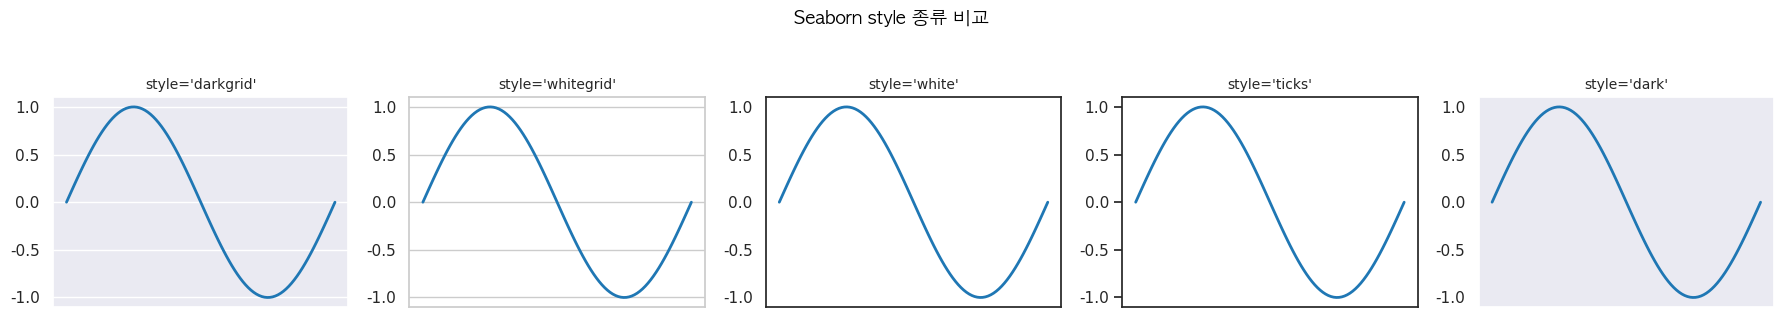

In [5]:
# 5가지 style 비교
styles = ['darkgrid', 'whitegrid', 'white', 'ticks', 'dark']
x = np.linspace(0, 2 * np.pi, 100)

fig = plt.figure(figsize=(18, 3))
for i, style in enumerate(styles):
    with sns.axes_style(style):
        # 1행 5열 중 (i+1)번째 축 생성
        ax = fig.add_subplot(1, 5, i + 1) 
        ax.plot(x, np.sin(x), lw=2)
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xticks([])

plt.suptitle('Seaborn style 종류 비교', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 2. 데이터 준비


| 데이터 | 출처 | 설명 |
| :--- | :--- | :--- |
| `df_sales`, `df_cust`, `df_ts` | 8·9장 재생성 | 쇼핑몰 판매·고객·시계열 |
| `tips` | `sns.load_dataset()` | 식당 팁 데이터 (244행) |
| `titanic` | `sns.load_dataset()` | 타이타닉 탑승자 데이터 (891행) |

In [7]:
# 8·9장 데이터 재생성
np.random.seed(42)

# 판매 데이터
data_sales = {
    '주문ID':   [f'ORD-{i:04d}' for i in range(1, 25)],
    '지역':     ['서울','서울','부산','부산','대구','서울','부산','대구',
                 '서울','서울','부산','서울','대구','부산','대구','서울',
                 '부산','서울','대구','서울','부산','대구','서울','부산'],
    '카테고리':  ['전자제품','의류','전자제품','식품','의류','식품','전자제품','의류',
                 '식품','전자제품','의류','전자제품','식품','전자제품','의류','식품',
                 '전자제품','의류','전자제품','식품','의류','전자제품','식품','의류'],
    '분기':     ['Q1','Q1','Q1','Q1','Q1','Q1','Q2','Q2',
                 'Q2','Q2','Q2','Q3','Q3','Q3','Q3','Q3',
                 'Q3','Q4','Q4','Q4','Q4','Q4','Q4','Q4'],
    '매출':     [1200000,85000,950000,42000,120000,55000,870000,95000,
                 38000,1100000,76000,980000,61000,1050000,88000,49000,
                 920000,105000,1300000,72000,91000,1150000,66000,83000],
    '수량':     [2,3,1,5,2,4,1,3,6,2,4,1,7,2,3,5,1,2,3,8,4,2,9,3]
}
df_sales = pd.DataFrame(data_sales)

# 고객 데이터
data_customer = {
    '고객ID':    [f'C{i:03d}' for i in range(1, 16)],
    '나이':      [23, 35, 42, 28, 51, 19, 67, 31, 44, 56, 38, 25, 72, 48, 33],
    '연간구매액': [850000,2300000,1500000,450000,3800000,120000,5200000,
                  1800000,2700000,4100000,950000,330000,6800000,3200000,1100000],
    '구매횟수':  [3,12,7,2,18,1,24,9,14,20,4,2,30,15,5]
}
df_cust = pd.DataFrame(data_customer)
bins_grade = [0, 500000, 1500000, 3000000, float('inf')]
labels_grade = ['일반', '실버', '골드', 'VIP']
df_cust['고객등급'] = pd.cut(df_cust['연간구매액'], bins=bins_grade, labels=labels_grade)

# 시계열 데이터
np.random.seed(0)
dates = pd.date_range(start='2024-01-01', end='2024-03-31', freq='D')
trend = np.linspace(500000, 800000, len(dates))
weekday_effect = np.where(pd.Series(dates).dt.dayofweek >= 5, 1.3, 1.0)
noise = np.random.normal(0, 50000, len(dates))
df_ts = pd.DataFrame({
    '날짜': dates,
    '일별매출': (trend * weekday_effect + noise).astype(int),
    '방문자수': np.random.normal(1500, 200, len(dates)).astype(int)
}).set_index('날짜')

print('판매 데이터:', df_sales.shape)
print('고객 데이터:', df_cust.shape)
print('시계열 데이터:', df_ts.shape)

판매 데이터: (24, 6)
고객 데이터: (15, 5)
시계열 데이터: (91, 2)


In [8]:
# Seaborn 내장 데이터셋 로드
tips    = sns.load_dataset('tips')      # 식당 팁 데이터
titanic = sns.load_dataset('titanic')   # 타이타닉 데이터
tips = tips.rename(columns = {'sex':'gender'})
titanic = titanic.rename(columns = {'sex':'gender'})

print('=== tips 데이터셋 (244행) ===')
display(tips.tail(5))
print('\n컬럼:', tips.columns.tolist())

print('\n=== titanic 데이터셋 (891행) ===')
display(titanic[['survived','pclass','gender','age','fare','embarked']].tail(5))

=== tips 데이터셋 (244행) ===


,total_bill,tip,gender,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2



컬럼: ['total_bill', 'tip', 'gender', 'smoker', 'day', 'time', 'size']

=== titanic 데이터셋 (891행) ===


,survived,pclass,gender,age,fare,embarked
886,0,2,male,27.0,13.00,S
887,1,1,female,19.0,30.00,S
888,0,3,female,NaN,23.45,S
889,1,1,male,26.0,30.00,C
890,0,3,male,32.0,7.75,Q


---
## 3. Axes-level 함수

Seaborn의 함수는 크게 두 종류로 나뉨. 먼저 **Axes-level 함수**를 살펴본다.

<div class="alert alert-block alert-info">
<b>💡 Axes-level 함수란?</b><br>
Matplotlib의 <code>ax.plot()</code>처럼 <b>하나의 Axes 객체에 그래프를 그리는 함수</b>.
반환값이 <code>Axes</code>이므로 <code>ax = sns.함수()</code>로 받을 수 있고,
이후 <code>ax.set_title()</code> 등 Matplotlib 코드로 자유롭게 커스터마이징 가능.
</div>

| 카테고리 | Axes-level 함수 | 용도 |
| :--- | :--- | :--- |
| **분포** | `histplot`, `kdeplot`, `ecdfplot`, `rugplot` | 수치 변수의 분포 파악 |
| **관계** | `scatterplot`, `lineplot` | 두 수치 변수 간 관계 |
| **범주형** | `boxplot`, `violinplot`, `barplot`, `stripplot`, `swarmplot`, `pointplot` | 범주별 수치 비교 |

#### 3-1. 분포 시각화 — histplot & kdeplot

```python
sns.histplot(
    data=df,          # DataFrame
    x='컬럼명',        # x축 변수
    hue='범주컬럼',    # 색상으로 구분할 범주
    bins=20,          # 구간 수
    kde=True,         # KDE 곡선 오버레이
    stat='count',     # 'count' | 'density' | 'probability'
    ax=ax             # 그릴 Axes 지정 (Figure-level과의 차이점!)
)
```

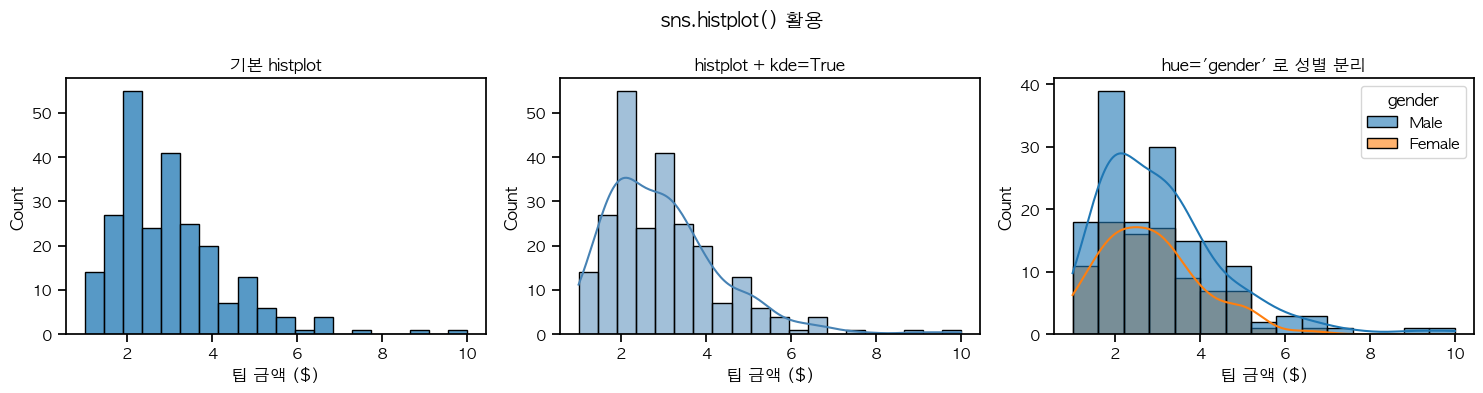

In [11]:
# histplot: tips 데이터 - 팁 금액 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 기본 히스토그램
sns.histplot(data=tips, x='tip', bins=20, ax=axes[0])
axes[0].set_title('기본 histplot', fontsize=12, fontweight='bold')
axes[0].set_xlabel('팁 금액 ($)')

# KDE 오버레이
sns.histplot(data=tips, x='tip', bins=20, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('histplot + kde=True', fontsize=12, fontweight='bold')
axes[1].set_xlabel('팁 금액 ($)')

# hue로 범주 구분
sns.histplot(data=tips, x='tip', hue='gender', bins=15, kde=True, alpha=0.6, ax=axes[2])
axes[2].set_title('hue=\'gender\' 로 성별 분리', fontsize=12, fontweight='bold')
axes[2].set_xlabel('팁 금액 ($)')

plt.suptitle('sns.histplot() 활용', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

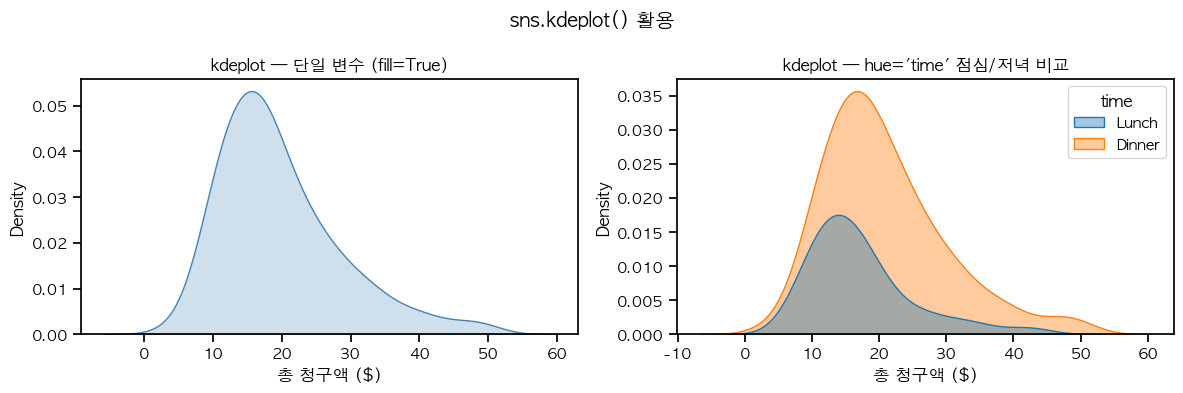

In [12]:
# kdeplot: 밀도 곡선만 단독으로
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 단일 변수 KDE
sns.kdeplot(data=tips, x='total_bill', fill=True, color='steelblue', ax=axes[0])
axes[0].set_title('kdeplot — 단일 변수 (fill=True)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('총 청구액 ($)')

# 그룹별 KDE (hue)
sns.kdeplot(data=tips, x='total_bill', hue='time', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('kdeplot — hue=\'time\' 점심/저녁 비교', fontsize=12, fontweight='bold')
axes[1].set_xlabel('총 청구액 ($)')

plt.suptitle('sns.kdeplot() 활용', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3-2. 관계 시각화 — scatterplot & lineplot

```python
sns.scatterplot(
    data=df,
    x='수치변수1', y='수치변수2',
    hue='범주컬럼',   # 색상
    size='수치컬럼',  # 점 크기
    style='범주컬럼', # 점 모양
    ax=ax
)
```

<div class="alert alert-block alert-info">
<b>💡 Seaborn scatterplot vs Matplotlib scatter의 가장 큰 차이</b><br>
Matplotlib에서는 그룹별 색상을 위해 <code>for</code> 루프를 직접 돌려야 했지만,
Seaborn에서는 <code>hue='컬럼명'</code> 파라미터 하나로 자동 처리된다.
</div>

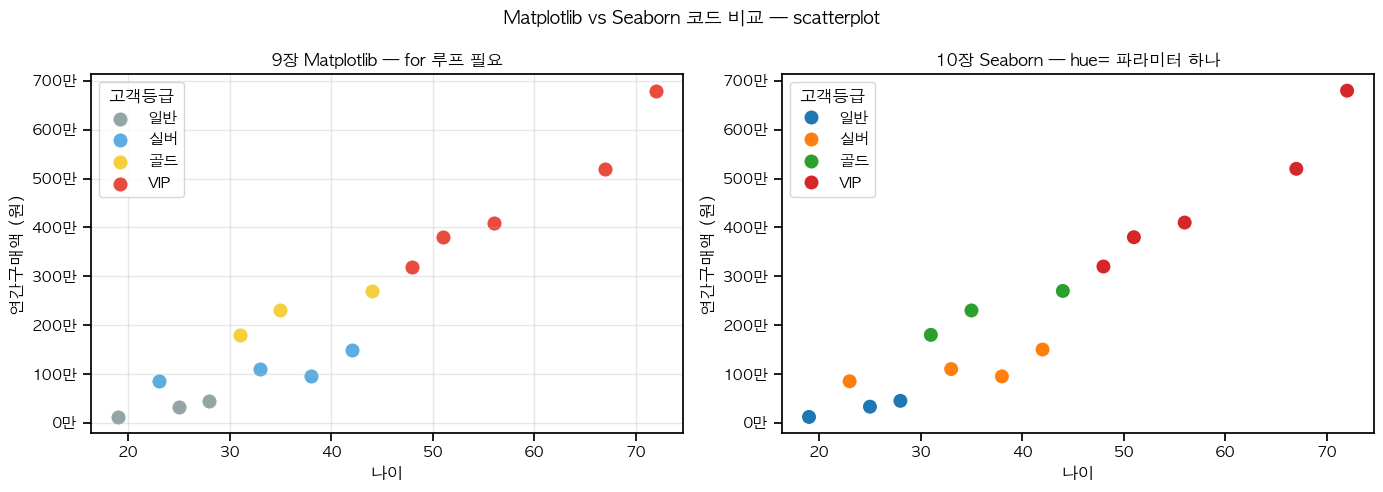

In [14]:
# scatterplot: 9장 코드와 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [좌] 9장 Matplotlib 방식 (for 루프 필요)
grade_colors = {'일반':'#95A5A6','실버':'#5DADE2','골드':'#F4D03F','VIP':'#E74C3C'}
for grade, group in df_cust.groupby('고객등급', observed=True):
    axes[0].scatter(group['나이'], group['연간구매액'],
                    c=grade_colors[grade], s=120, label=grade,
                    edgecolors='white', linewidths=0.8)
axes[0].set_title('9장 Matplotlib — for 루프 필요', fontsize=12, fontweight='bold')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('연간구매액 (원)')
axes[0].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[0].legend(title='고객등급')
axes[0].grid(True, alpha=0.3)

# [우] 10장 Seaborn 방식 (한 줄)
sns.scatterplot(data=df_cust, x='나이', y='연간구매액',
                hue='고객등급', s=120, ax=axes[1])
axes[1].set_title('10장 Seaborn — hue= 파라미터 하나', fontsize=12, fontweight='bold')
axes[1].set_xlabel('나이')
axes[1].set_ylabel('연간구매액 (원)')
axes[1].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))

plt.suptitle('Matplotlib vs Seaborn 코드 비교 — scatterplot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

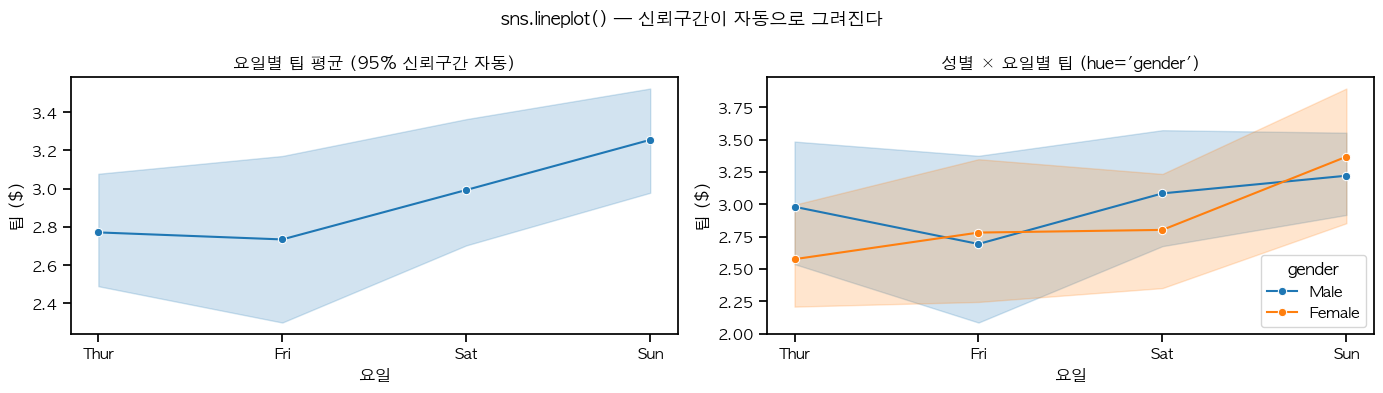

In [15]:
# lineplot: 시계열 데이터 + 신뢰구간 자동 생성
# tips 데이터로 요일별 팁 평균 + 신뢰구간
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 요일별 팁 평균 (신뢰구간 자동)
sns.lineplot(data=tips, x='day', y='tip', 
             marker='o', ax=axes[0])
axes[0].set_title('요일별 팁 평균 (95% 신뢰구간 자동)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('팁 ($)')

# hue 추가: 성별 × 요일 교차
sns.lineplot(data=tips, x='day', y='tip', hue='gender',
             marker='o', ax=axes[1])
axes[1].set_title('성별 × 요일별 팁 (hue=\'gender\')', fontsize=12, fontweight='bold')
axes[1].set_xlabel('요일')
axes[1].set_ylabel('팁 ($)')

plt.suptitle('sns.lineplot() — 신뢰구간이 자동으로 그려진다', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3-3. 범주형 시각화 — boxplot, violinplot, barplot

| 함수 | 특징 | 언제? |
| :--- | :--- | :--- |
| `boxplot` | 중앙값·IQR·이상치 요약 | 분포 요약 + 이상치 확인 |
| `violinplot` | KDE 모양으로 분포 형태까지 표현 | 분포 형태가 중요할 때 |
| `barplot` | 평균 + 오차 막대 | 그룹별 평균 비교 |
| `stripplot` | 실제 데이터 점으로 표시 | 데이터 수가 적을 때 |
| `swarmplot` | 겹치지 않게 점 배치 | stripplot + 가독성 |
| `pointplot` | 점 + 신뢰구간 선 연결 | 그룹 평균 추세 비교 |

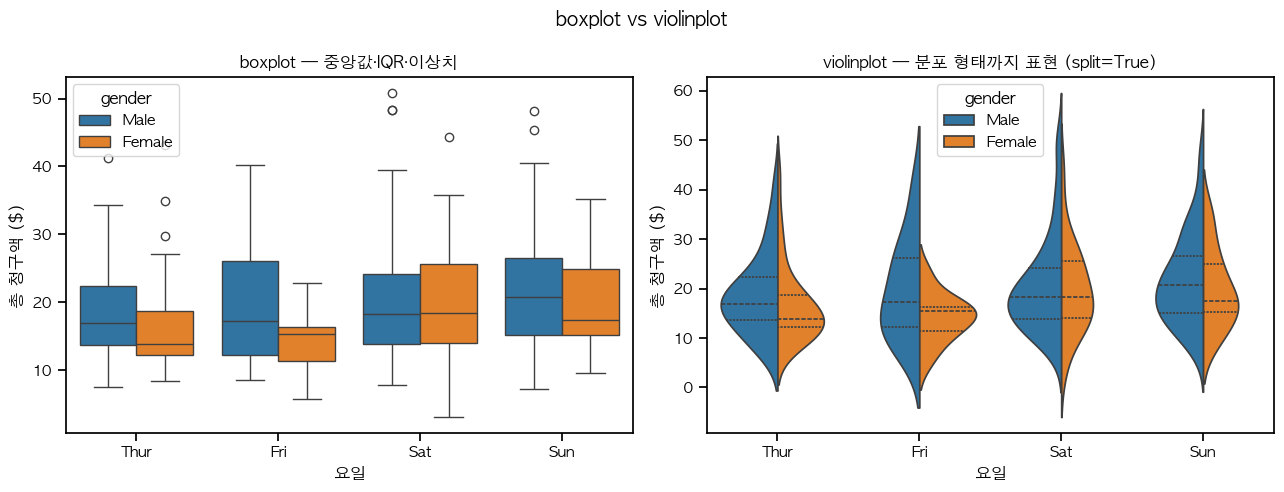

In [17]:
# boxplot vs violinplot 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=tips, x='day', y='total_bill', hue='gender',
            order=['Thur','Fri','Sat','Sun'], ax=axes[0])
axes[0].set_title('boxplot — 중앙값·IQR·이상치', fontsize=12, fontweight='bold')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('총 청구액 ($)')

sns.violinplot(data=tips, x='day', y='total_bill', hue='gender',
               order=['Thur','Fri','Sat','Sun'], split=True,
               inner='quart', ax=axes[1])
axes[1].set_title('violinplot — 분포 형태까지 표현 (split=True)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('요일')
axes[1].set_ylabel('총 청구액 ($)')

plt.suptitle('boxplot vs violinplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

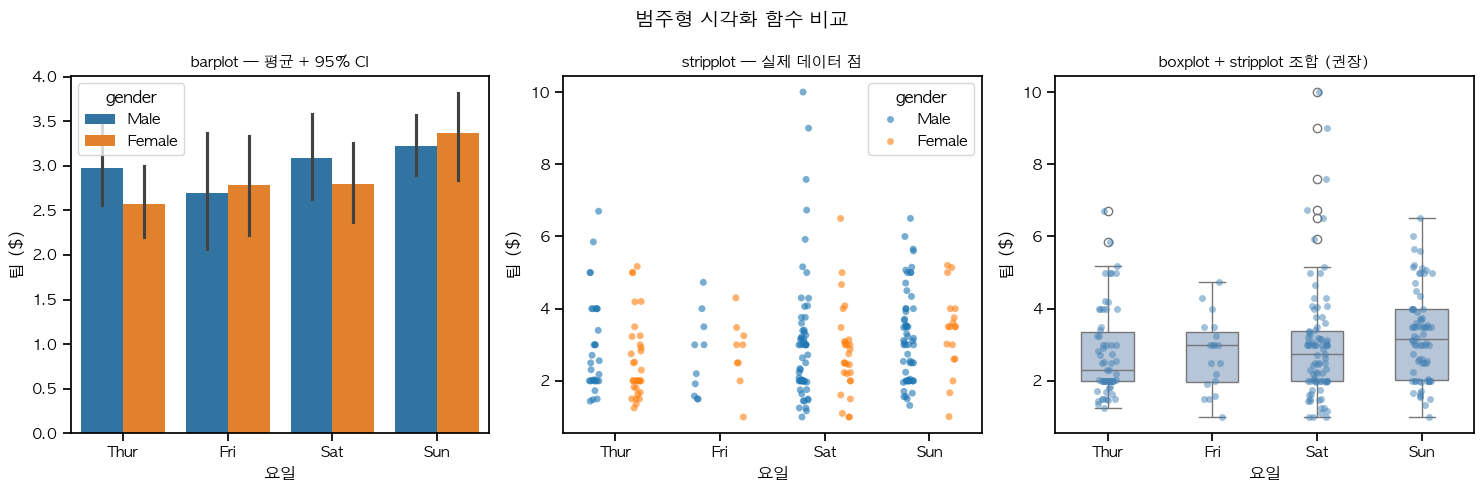

In [18]:
# barplot + stripplot 조합 (실무에서 자주 씀)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# barplot: 평균 + 오차 막대
sns.barplot(data=tips, x='day', y='tip', hue='gender',
            order=['Thur','Fri','Sat','Sun'], ax=axes[0])
axes[0].set_title('barplot — 평균 + 95% CI', fontsize=11, fontweight='bold')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('팁 ($)')

# stripplot: 실제 데이터 포인트
sns.stripplot(data=tips, x='day', y='tip', hue='gender',
              order=['Thur','Fri','Sat','Sun'],
              jitter=True, dodge=True, alpha=0.6, ax=axes[1])
axes[1].set_title('stripplot — 실제 데이터 점', fontsize=11, fontweight='bold')
axes[1].set_xlabel('요일')
axes[1].set_ylabel('팁 ($)')

# boxplot + stripplot 조합 (실무 표준)
sns.boxplot(data=tips, x='day', y='tip',
            order=['Thur','Fri','Sat','Sun'],
            color='lightsteelblue', width=0.5, ax=axes[2])
sns.stripplot(data=tips, x='day', y='tip',
              order=['Thur','Fri','Sat','Sun'],
              color='steelblue', alpha=0.5, jitter=True, ax=axes[2])
axes[2].set_title('boxplot + stripplot 조합 (권장)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('요일')
axes[2].set_ylabel('팁 ($)')

plt.suptitle('범주형 시각화 함수 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> #### Exercise — Axes-level 함수
> `tips` 데이터셋을 사용하여 다음 그래프를 `plt.subplots(1, 3)`으로 나란히 그리시오.
> 1. `[0]`: `total_bill` 분포를 `hue='smoker'`로 구분한 **histplot** (kde=True)
> 2. `[1]`: `total_bill` vs `tip` 산점도를 `hue='time'`으로 구분한 **scatterplot** (size='size'도 추가)
> 3. `[2]`: `smoker` × `day` 별 `tip` 평균 **barplot** (x='smoker', hue='day')
> - 각 그래프에 `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` 추가

In [20]:
# 여기에 코드를 작성하시오.


---
## 4. Figure-level 함수

<div class="alert alert-block alert-warning">
<b>⚠️ Figure-level 함수 — 핵심 개념</b><br>
Figure-level 함수는 내부에서 자동으로 <b>Figure와 Axes를 새로 생성</b>한다.
반환값이 <code>Axes</code>가 아니라 <code>FacetGrid</code> 또는 <code>PairGrid</code> 객체이며,
가장 강력한 기능은 <b>col=, row= 파라미터로 데이터를 자동 분할하여 패널을 생성</b>하는 것이다.
</div>

| Figure-level 함수 | 내부에서 사용하는 Axes-level 함수 | 카테고리 |
| :--- | :--- | :--- |
| `relplot()` | `scatterplot`, `lineplot` | 관계 시각화 |
| `displot()` | `histplot`, `kdeplot`, `ecdfplot` | 분포 시각화 |
| `catplot()` | `boxplot`, `violinplot`, `barplot`, `stripplot` 등 | 범주형 시각화 |

#### 4-1. relplot() — 관계 시각화의 Figure-level 버전

```python
sns.relplot(
    data=df,
    x='컬럼', y='컬럼',
    kind='scatter',   # 'scatter' | 'line'
    hue='범주',
    col='범주',        # 열 방향으로 패널 분할 ← Figure-level 전용!
    row='범주',        # 행 방향으로 패널 분할 ← Figure-level 전용!
    col_wrap=3         # 한 행에 최대 N개 패널
)
```

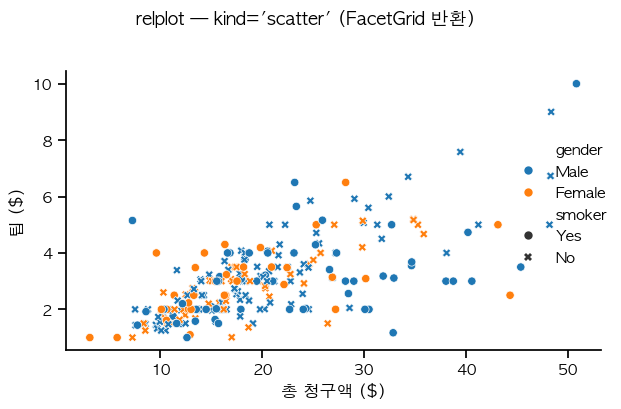

반환 타입: <class 'seaborn.axisgrid.FacetGrid'>
내부 axes 타입: <class 'matplotlib.axes._axes.Axes'>


In [23]:
# relplot 기본 — scatterplot과 동일하지만 Figure-level
g = sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    hue='gender', style='smoker',
    kind='scatter',
    height=4, aspect=1.3
)
g.set_axis_labels('총 청구액 ($)', '팁 ($)')
g.figure.suptitle('relplot — kind=\'scatter\' (FacetGrid 반환)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'반환 타입: {type(g)}')
print(f'내부 axes 타입: {type(g.axes[0][0])}')

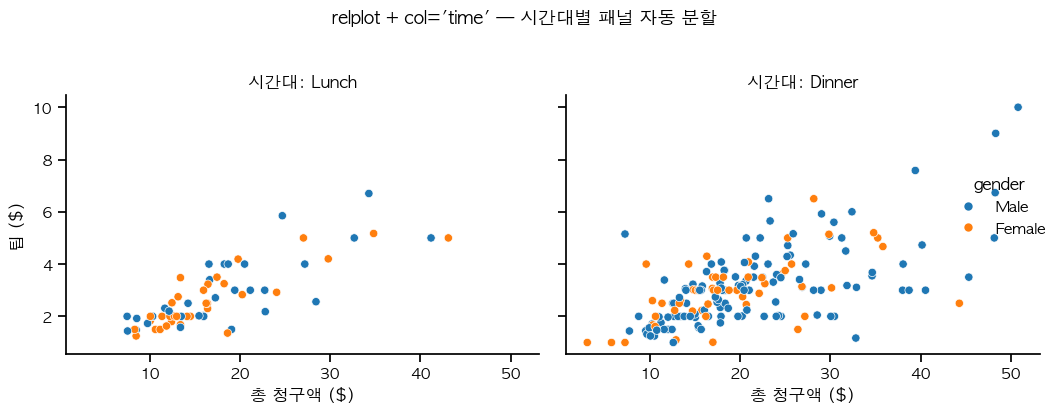

In [24]:
# relplot의 진짜 강점: col= 로 자동 패널 분할
g = sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    hue='gender',
    col='time',          # 점심 / 저녁 패널 자동 분할
    kind='scatter',
    height=4, aspect=1.2
)
g.set_axis_labels('총 청구액 ($)', '팁 ($)')
g.set_titles('시간대: {col_name}')   # 각 패널 제목 형식 지정
g.figure.suptitle('relplot + col=\'time\' — 시간대별 패널 자동 분할', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

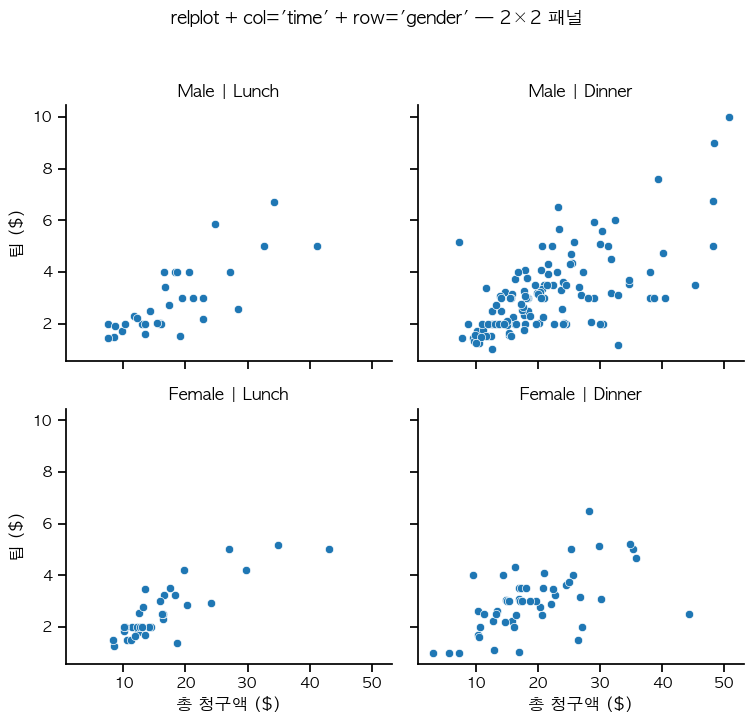

In [25]:
# col + row 동시 사용 — 2차원 패널 격자
g = sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    col='time', row='gender',   # 2×2 패널 격자
    kind='scatter',
    height=3.5, aspect=1.1
)
g.set_axis_labels('총 청구액 ($)', '팁 ($)')
g.set_titles('{row_name} | {col_name}')
g.figure.suptitle('relplot + col=\'time\' + row=\'gender\' — 2×2 패널', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4-2. displot() — 분포 시각화의 Figure-level 버전

```python
sns.displot(
    data=df,
    x='컬럼',
    kind='hist',   # 'hist' | 'kde' | 'ecdf'
    hue='범주',
    col='범주',     # 패널 분할
    rug=True       # 실제 데이터 위치 표시
)
```

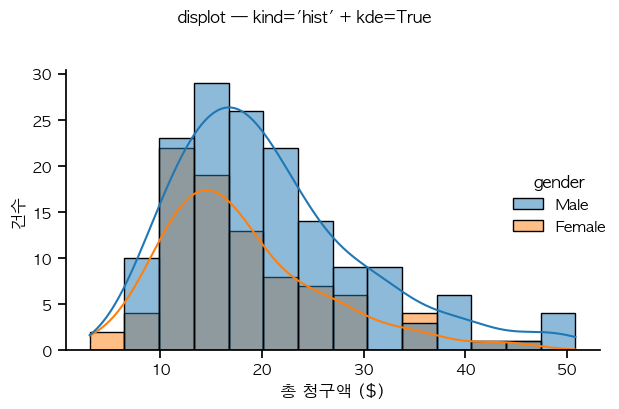

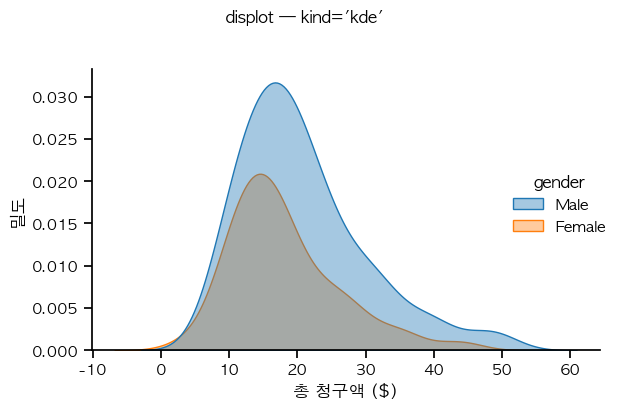

In [27]:
# displot: kind 변경으로 3가지 분포 차트
fig_d1 = sns.displot(data=tips, x='total_bill', kind='hist', kde=True,
                     hue='gender', height=4, aspect=1.3)
fig_d1.set_axis_labels('총 청구액 ($)', '건수')
fig_d1.figure.suptitle('displot — kind=\'hist\' + kde=True', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig_d2 = sns.displot(data=tips, x='total_bill', kind='kde',
                     hue='gender', fill=True, alpha=0.4, height=4, aspect=1.3)
fig_d2.set_axis_labels('총 청구액 ($)', '밀도')
fig_d2.figure.suptitle('displot — kind=\'kde\'', y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

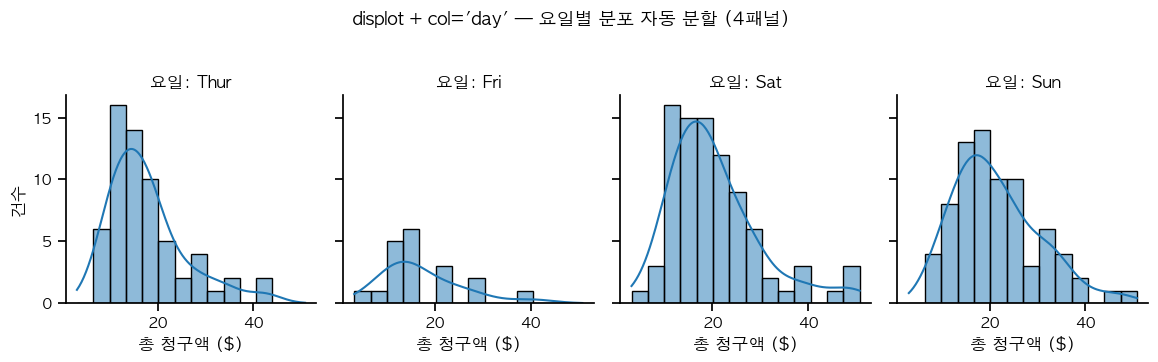

In [28]:
# displot + col 패널 분할
g = sns.displot(
    data=tips,
    x='total_bill',
    kind='hist', kde=True,
    col='day',                           # 요일별 패널
    col_order=['Thur','Fri','Sat','Sun'], # 순서 지정
    height=3.5, aspect=0.85
)
g.set_axis_labels('총 청구액 ($)', '건수')
g.set_titles('요일: {col_name}')
g.figure.suptitle('displot + col=\'day\' — 요일별 분포 자동 분할 (4패널)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4-3. catplot() — 범주형 시각화의 Figure-level 버전

```python
sns.catplot(
    data=df,
    x='범주', y='수치',
    kind='box',   # 'box' | 'violin' | 'bar' | 'strip' | 'swarm' | 'point'
    hue='범주',
    col='범주',   # 패널 분할
    col_wrap=2    # 한 행에 최대 2개
)
```

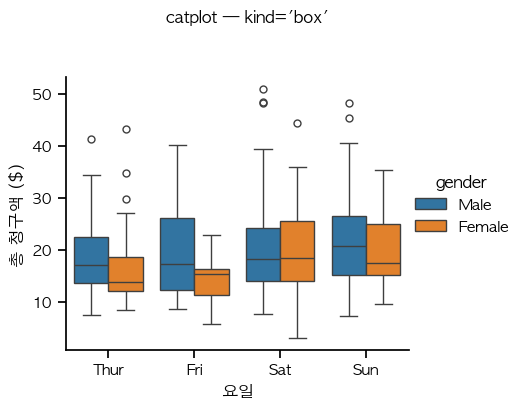

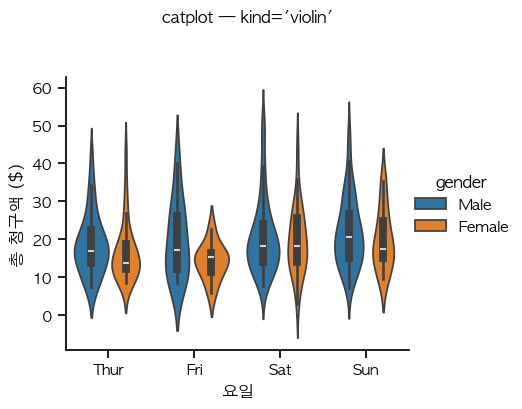

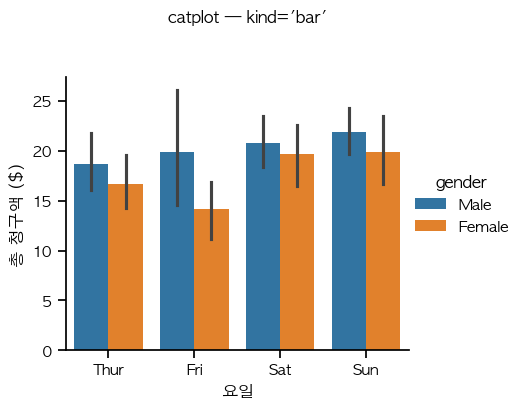

In [30]:
# catplot: kind= 하나만 바꾸면 차트 종류 전환
fig, axes_mock = plt.subplots(1, 3, figsize=(16, 5))
plt.close()   # mock figure 닫기 — catplot은 자체 Figure 생성

for kind in ['box', 'violin', 'bar']:
    g = sns.catplot(
        data=tips, x='day', y='total_bill', hue='gender',
        kind=kind,
        order=['Thur','Fri','Sat','Sun'],
        height=4, aspect=1.1
    )
    g.set_axis_labels('요일', '총 청구액 ($)')
    g.figure.suptitle(f"catplot — kind='{kind}'", y=1.02, fontsize=12, fontweight='bold')
    g.fig.subplots_adjust(top=0.85) # tight_layout 대신 subplots_adjust로 상단 타이틀 여백만 확보.
    # plt.tight_layout()
    plt.show()

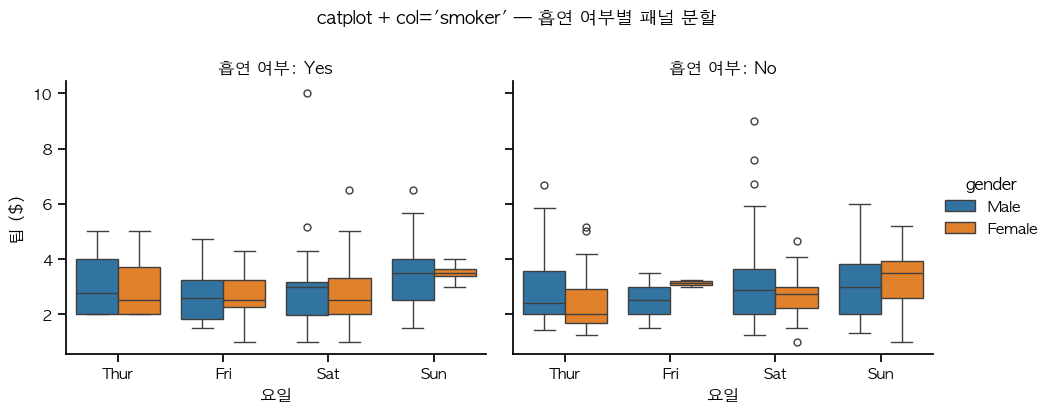

In [31]:
# catplot + col_wrap: 요일별 × 흡연 여부 패널 분할
g = sns.catplot(
    data=tips,
    x='day', y='tip', hue='gender',
    col='smoker',        # 흡연 여부로 패널 분할
    kind='box',
    order=['Thur','Fri','Sat','Sun'],
    height=4, aspect=1.2
)
g.set_axis_labels('요일', '팁 ($)')
g.set_titles('흡연 여부: {col_name}')
g.figure.suptitle('catplot + col=\'smoker\' — 흡연 여부별 패널 분할', y=1.03, fontsize=13, fontweight='bold')
g.fig.subplots_adjust(top=0.85)
plt.show()

> #### Exercise — Figure-level 함수
> `titanic` 데이터셋을 사용하여 다음을 수행하시오.
> 1. `fare`(요금) 분포를 `hue='survived'`(생존 여부), `col='pclass'`(객실 등급)로 분할한 **displot** (kind='kde', fill=True)을 그리시오.
> 2. `pclass`별 `age` 분포를 `hue='gender'`로 구분한 **catplot** (kind='violin', split=True)을 그리시오.
> 3. `age` vs `fare` 산점도를 `hue='survived'`, `col='pclass'`로 분할한 **relplot**을 그리시오.
> - 각 Figure에 `g.figure.suptitle()`로 제목을 추가하시오.

In [33]:
# 여기에 코드를 작성하시오.


---
## 5. Figure-level vs Axes-level — 핵심 비교

이 장의 **핵심 개념**이다. 두 가지 함수 유형의 차이를 정확히 이해해야 올바르게 사용할 수 있다.

| 비교 항목 | Axes-level | Figure-level |
| :--- | :--- | :--- |
| **예시 함수** | `scatterplot`, `histplot`, `boxplot` | `relplot`, `displot`, `catplot` |
| **반환값** | `matplotlib.axes.Axes` | `seaborn.FacetGrid` |
| **Figure 생성** | 직접 생성 필요 (`plt.subplots()`) | 내부에서 자동 생성 |
| **크기 조절** | `figsize=(w, h)` | `height=h, aspect=비율` |
| **패널 분할** | ❌ 불가 | ✅ `col=`, `row=`, `col_wrap=` |
| **Matplotlib 통합** | 바로 가능 (`ax.set_title()`) | `g.ax.set_title()` 또는 `g.axes[0][0]` |
| **서브플롯 배치** | ✅ 자유롭게 배치 가능 | ❌ 단독 Figure로만 생성 |

#### 5-1. 반환값의 차이

Axes-level 반환 타입: <class 'matplotlib.axes._axes.Axes'>


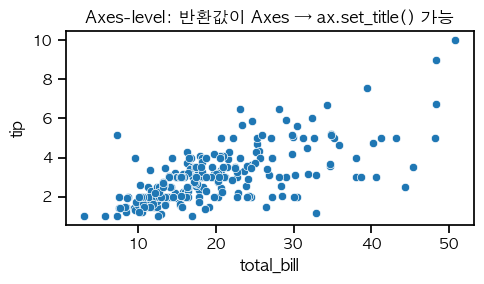

Figure-level 반환 타입: <class 'seaborn.axisgrid.FacetGrid'>


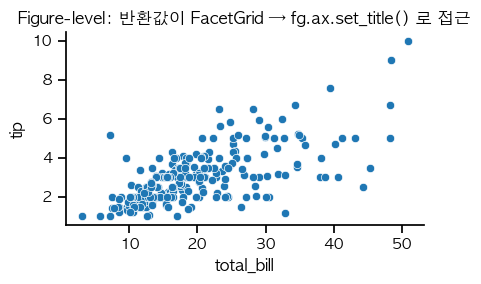

In [36]:
# 반환값 타입 비교
fig, ax = plt.subplots(figsize=(5, 3))

# Axes-level: 반환값 = Axes
ax_result = sns.scatterplot(data=tips, x='total_bill', y='tip', ax=ax)
print(f'Axes-level 반환 타입: {type(ax_result)}')
# → Axes이므로 Matplotlib API 바로 사용
ax_result.set_title('Axes-level: 반환값이 Axes → ax.set_title() 가능')
plt.tight_layout()
plt.show()

# Figure-level: 반환값 = FacetGrid
fg_result = sns.relplot(data=tips, x='total_bill', y='tip', kind='scatter',
                        height=3, aspect=1.5)
print(f'Figure-level 반환 타입: {type(fg_result)}')
# → FacetGrid이므로 .ax 또는 .axes 속성으로 접근
fg_result.ax.set_title('Figure-level: 반환값이 FacetGrid → fg.ax.set_title() 로 접근')
plt.tight_layout()
plt.show()

#### 5-2. 크기 조절 방식의 차이

```python
# Axes-level: plt.subplots()에서 figsize로 전체 Figure 크기 지정
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=tips, x='tip', ax=ax)

# Figure-level: 개별 패널(서브플롯) 하나의 크기를 height와 aspect로 지정
#   전체 Figure 크기 = height × (패널 수 × aspect)
g = sns.displot(data=tips, x='tip', col='gender', height=4, aspect=1.2)
#   → 패널 1개: 4인치 × 4.8인치
#   → 2패널 합산: 4인치 × 9.6인치
```

=== Axes-level: figsize로 전체 크기 조절 ===


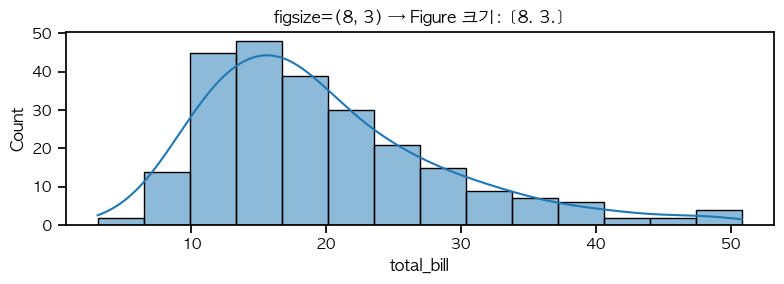


=== Figure-level: height + aspect로 패널 크기 조절 ===


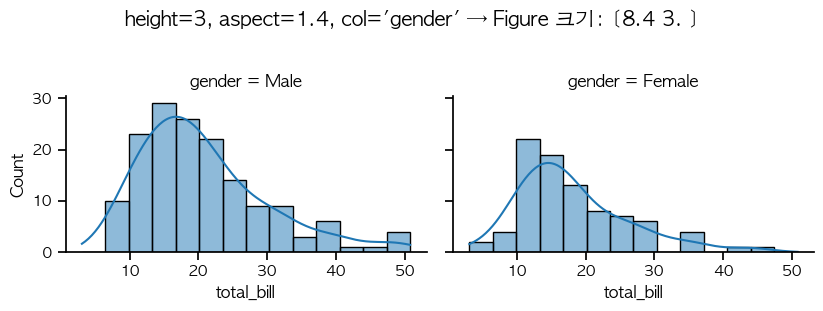

In [38]:
# 크기 조절 방식 직접 비교
print('=== Axes-level: figsize로 전체 크기 조절 ===')
fig, ax = plt.subplots(figsize=(8, 3))   # 전체 Figure 크기
sns.histplot(data=tips, x='total_bill', kde=True, ax=ax)
ax.set_title(f'figsize=(8, 3) → Figure 크기: {fig.get_size_inches()}')
plt.tight_layout()
plt.show()

print('\n=== Figure-level: height + aspect로 패널 크기 조절 ===')
g = sns.displot(data=tips, x='total_bill', kde=True,
                col='gender', height=3, aspect=1.4)   # 패널 1개 크기
size = g.figure.get_size_inches()
g.figure.suptitle(f'height=3, aspect=1.4, col=\'gender\' → Figure 크기: {size.round(1)}', y=1.03)
plt.tight_layout()
plt.show()

#### 5-3. Matplotlib 커스터마이징과의 통합

<div class="alert alert-block alert-success">
<b>실무 패턴 요약</b><br>

<b>Axes-level 사용 시 → Matplotlib과 완전히 동일</b>
```python
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=tips, x='day', y='tip', ax=ax)
ax.set_title('제목')          # 바로 사용 가능
ax.set_xlabel('요일')
ax.set_ylabel('팁 ($)')
```

<b>Figure-level 사용 시 → FacetGrid 메서드 또는 .ax 접근</b>
```python
g = sns.catplot(data=tips, x='day', y='tip', kind='box')
g.set_axis_labels('요일', '팁 ($)')   # FacetGrid 전용 메서드
g.set_titles('{col_name}')             # 각 패널 제목
g.ax.set_title('단일 패널일 때 제목')  # 단일 패널: .ax
g.axes[0][0].set_title('...')          # 다중 패널: .axes[행][열]
g.figure.suptitle('전체 제목', y=1.02) # 전체 Figure 제목
```
</div>

/var/folders/wv/qlkf8lb51w70xm32df60g6v40000gn/T/ipykernel_64902/2435485420.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='tip',


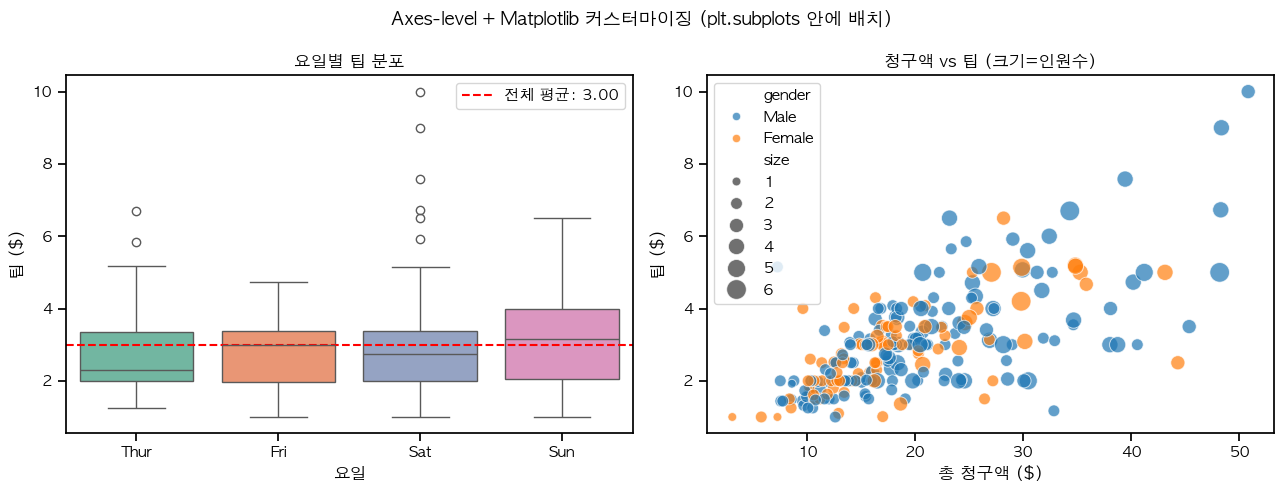

In [40]:
# Axes-level + Matplotlib 커스터마이징 (가장 자유롭고 권장)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Axes-level + Matplotlib 커스터마이징 (plt.subplots 안에 배치)', fontsize=13, fontweight='bold')

# 왼쪽 패널
sns.boxplot(data=tips, x='day', y='tip',
            order=['Thur','Fri','Sat','Sun'],
            palette='Set2', ax=axes[0])
axes[0].set_title('요일별 팁 분포', fontsize=12)
axes[0].set_xlabel('요일')
axes[0].set_ylabel('팁 ($)')
axes[0].axhline(tips['tip'].mean(), color='red', ls='--', lw=1.5, label=f'전체 평균: {tips["tip"].mean():.2f}')
axes[0].legend()

# 오른쪽 패널
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='gender', size='size', sizes=(40, 200),
                alpha=0.7, ax=axes[1])
axes[1].set_title('청구액 vs 팁 (크기=인원수)', fontsize=12)
axes[1].set_xlabel('총 청구액 ($)')
axes[1].set_ylabel('팁 ($)')

plt.tight_layout()
plt.show()

#### 5-4. 언제 무엇을 쓰나?

<div class="alert alert-block alert-info">
<b>💡 선택 가이드</b><br>

| 상황 | 추천 |
| :--- | :--- |
| 여러 그래프를 `plt.subplots()`로 배치하고 싶다 | **Axes-level** |
| Matplotlib 코드와 섞어 쓰고 싶다 | **Axes-level** |
| 그래프 1개만 빠르게 탐색하고 싶다 | **둘 다 가능** |
| 범주 기준으로 패널을 자동 분할하고 싶다 | **Figure-level** (`col=`, `row=`) |
| "지역별로 나눠서 보여줘" 같은 요청 | **Figure-level** |
</div>

/var/folders/wv/qlkf8lb51w70xm32df60g6v40000gn/T/ipykernel_64902/591442209.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='tip',


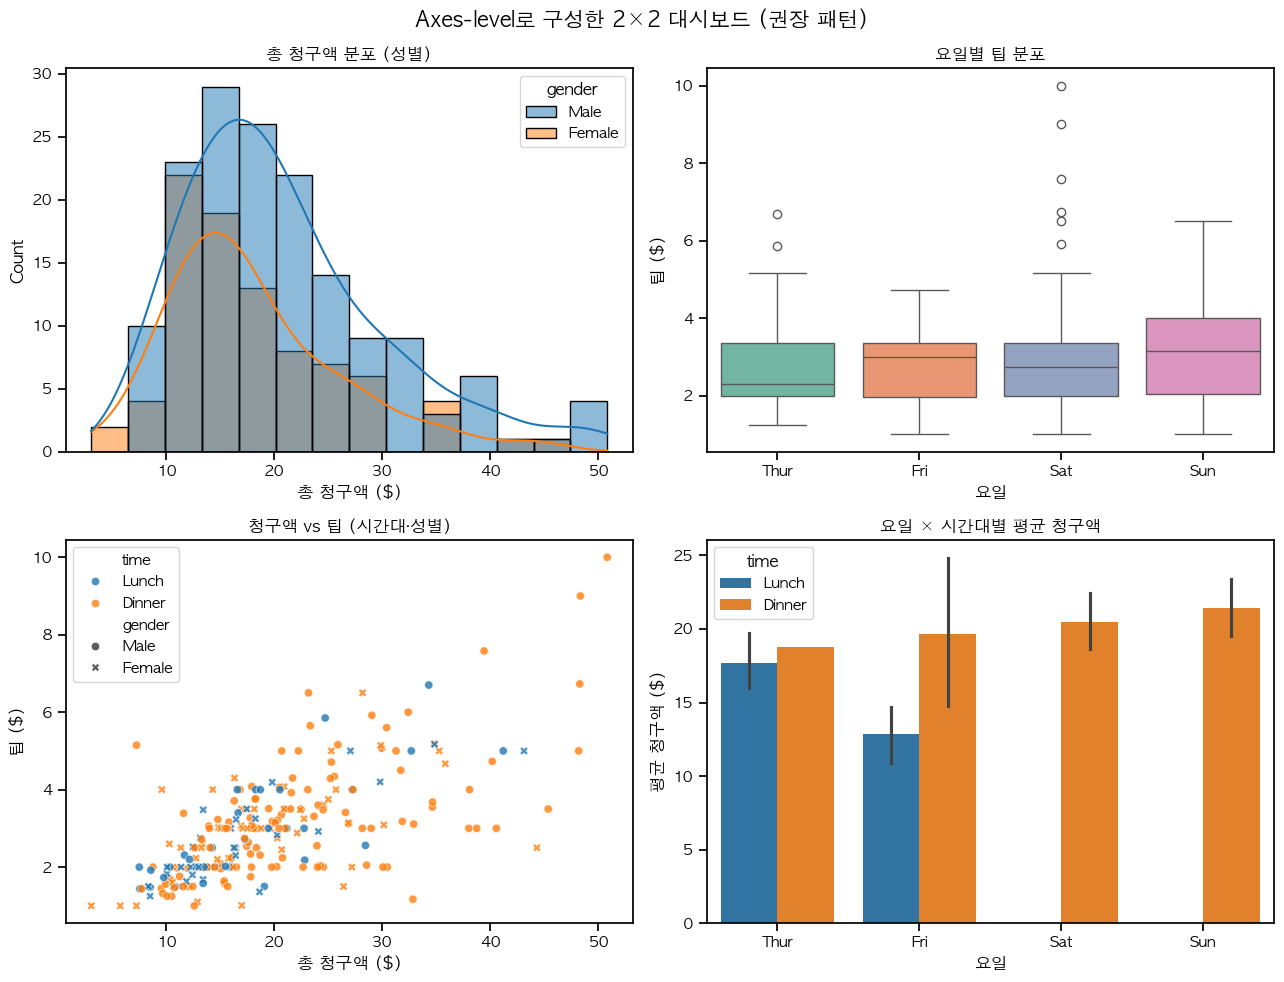

In [42]:
# 실전 선택: 서브플롯 안에 Seaborn 차트를 넣어야 할 때 → Axes-level
# (Figure-level은 자체 Figure를 만들기 때문에 이 패턴이 불가능)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Axes-level로 구성한 2×2 대시보드 (권장 패턴)', fontsize=15, fontweight='bold')

# [0,0] 히스토그램
sns.histplot(data=tips, x='total_bill', hue='gender', kde=True, ax=axes[0,0])
axes[0,0].set_title('총 청구액 분포 (성별)')
axes[0,0].set_xlabel('총 청구액 ($)')

# [0,1] 박스플롯
sns.boxplot(data=tips, x='day', y='tip',
            order=['Thur','Fri','Sat','Sun'], palette='Set2', ax=axes[0,1])
axes[0,1].set_title('요일별 팁 분포')
axes[0,1].set_xlabel('요일')
axes[0,1].set_ylabel('팁 ($)')

# [1,0] 산점도
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='time', style='gender', alpha=0.8, ax=axes[1,0])
axes[1,0].set_title('청구액 vs 팁 (시간대·성별)')
axes[1,0].set_xlabel('총 청구액 ($)')
axes[1,0].set_ylabel('팁 ($)')

# [1,1] 막대 그래프
sns.barplot(data=tips, x='day', y='total_bill', hue='time',
            order=['Thur','Fri','Sat','Sun'], ax=axes[1,1])
axes[1,1].set_title('요일 × 시간대별 평균 청구액')
axes[1,1].set_xlabel('요일')
axes[1,1].set_ylabel('평균 청구액 ($)')

plt.tight_layout()
plt.show()

> #### Exercise — Figure-level vs Axes-level 선택
> 아래 두 가지 요구사항을 각각 올바른 함수 유형으로 구현하시오.
>
> **요구사항 A** (Axes-level 사용)
> `tips` 데이터로 `plt.subplots(1, 2, figsize=(12, 4))`를 만들고,
> - `[0]`: `sns.violinplot` — smoker × day별 tip (hue='gender')
> - `[1]`: `sns.barplot` — gender × time별 total_bill (hue='gender')
>
> **요구사항 B** (Figure-level 사용)
> `tips` 데이터로 `sns.catplot`을 사용하여, `smoker` 기준으로 패널을 분할하고, 각 패널에서 `day` × `tip` 바이올린 플롯을 성별(`hue='gender'`)로 비교하시오.

In [44]:
# 여기에 코드를 작성하시오.


---
## 6. FacetGrid 심화 — col/row 패널 분할

Figure-level 함수의 핵심 기능인 **FacetGrid**를 직접 사용하면 더욱 세밀한 제어가 가능하다.
Figure-level 함수(relplot, displot, catplot)는 내부적으로 FacetGrid를 사용하며,
`FacetGrid.map()` 또는 `FacetGrid.map_dataframe()`으로 어떤 플롯 함수도 연결할 수 있다.

```python
g = sns.FacetGrid(
    data=df,
    col='범주컬럼',     # 열 방향 패널
    row='범주컬럼',     # 행 방향 패널
    hue='범주컬럼',     # 색상 구분
    col_wrap=N,         # 한 행 최대 패널 수
    height=4,
    aspect=1.2
)
g.map_dataframe(sns.histplot, x='컬럼')   # 각 패널에 그릴 함수 지정
g.add_legend()                            # 범례 추가
g.set_axis_labels('x축명', 'y축명')
g.set_titles('{col_name}')
```

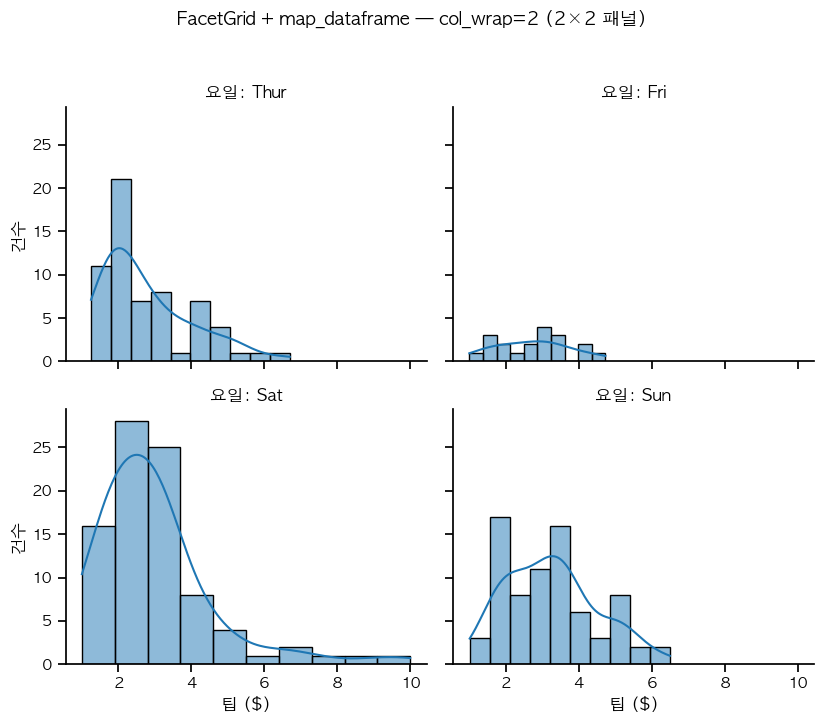

In [46]:
# FacetGrid 직접 사용: col_wrap으로 자동 줄바꿈
g = sns.FacetGrid(
    data=tips,
    col='day',
    col_order=['Thur','Fri','Sat','Sun'],
    col_wrap=2,          # 2개씩 줄바꿈 → 2×2 배치
    height=3.5, aspect=1.2,
    sharey=True          # Y축 공유 (비교 용이)
)
g.map_dataframe(sns.histplot, x='tip', bins=10, kde=True)
g.set_axis_labels('팁 ($)', '건수')
g.set_titles('요일: {col_name}')
g.figure.suptitle('FacetGrid + map_dataframe — col_wrap=2 (2×2 패널)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

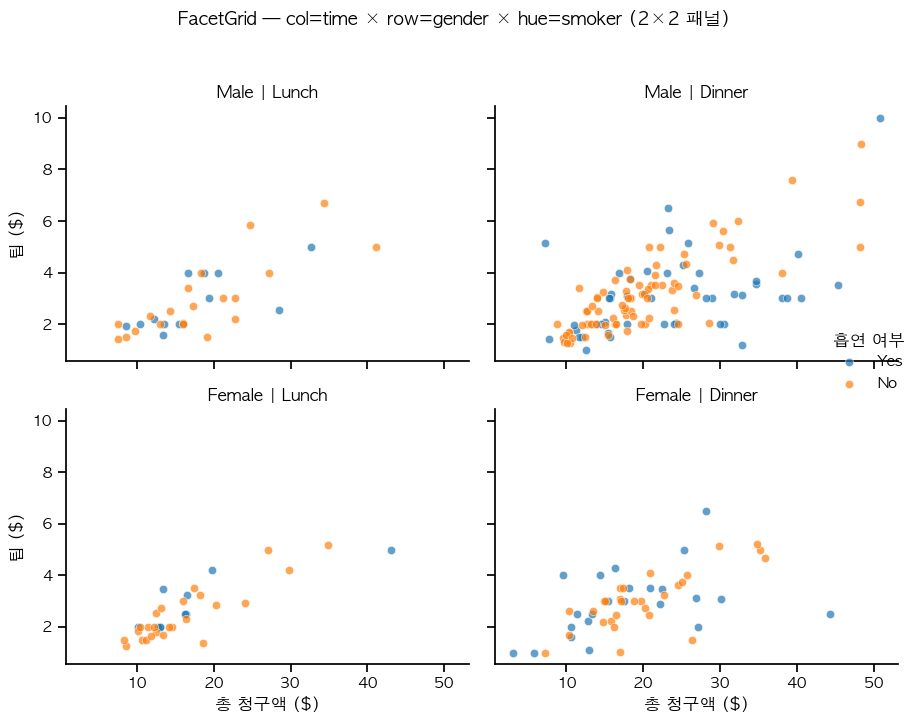

In [47]:
# FacetGrid + hue + 사용자 정의 함수
g = sns.FacetGrid(
    data=tips,
    col='time', row='gender',
    hue='smoker',
    height=3.5, aspect=1.2
)
g.map_dataframe(sns.scatterplot, x='total_bill', y='tip', alpha=0.7)
g.add_legend(title='흡연 여부')
g.set_axis_labels('총 청구액 ($)', '팁 ($)')
g.set_titles('{row_name} | {col_name}')
g.figure.suptitle('FacetGrid — col=time × row=gender × hue=smoker (2×2 패널)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

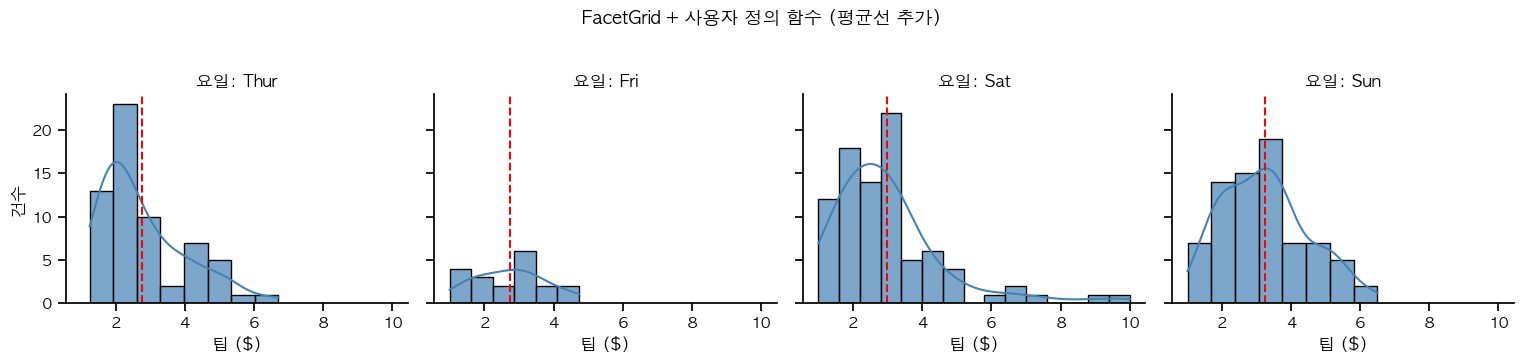

In [48]:
# FacetGrid.map_dataframe()에 Matplotlib 함수도 연결 가능
def plot_with_mean(data, x, **kwargs):
    """각 패널에 히스토그램 + 평균선을 그리는 사용자 정의 함수"""
    ax = plt.gca()
    sns.histplot(data=data, x=x, kde=True, ax=ax, **kwargs)
    mean_val = data[x].mean()
    ax.axvline(mean_val, color='red', ls='--', lw=1.5, label=f'평균: {mean_val:.1f}')
    ax.legend(fontsize=8)

g = sns.FacetGrid(data=tips, col='day', col_order=['Thur','Fri','Sat','Sun'],
                  height=3.5, aspect=1.1)
g.map_dataframe(plot_with_mean, x='tip', color='steelblue', alpha=0.7)
g.set_axis_labels('팁 ($)', '건수')
g.set_titles('요일: {col_name}')
g.figure.suptitle('FacetGrid + 사용자 정의 함수 (평균선 추가)', y=1.03, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> #### Exercise — FacetGrid
> `tips` 데이터셋을 활용하여 다음을 수행하시오.
> 1. `FacetGrid`를 사용하여 `smoker` × `gender` (col × row) 4패널 구조를 만들고,
>    각 패널에 `total_bill` vs `tip` 산점도를 그리시오. (`map_dataframe` 활용)
> 2. 요일(`day`)별로 패널을 분할하되 `col_wrap=2`로 2×2 배치하고,
>    각 패널에 `total_bill` KDE 곡선을 `hue='gender'`로 구분하여 그리시오.
>
> #### Advance — 쇼핑몰 데이터 종합 시각화
> 아래 이커머스 300건 데이터를 생성하고, Figure-level / Axes-level 함수를 적절히 선택하여
> 다음 분석 요구사항을 시각화하시오.
> 1. **카테고리별 패널** (`col='카테고리'`, `col_wrap=3`): 각 카테고리의 `판매가` 분포 (histplot + kde)
> 2. **지역 × 카테고리 대시보드** (`plt.subplots(2,3)`, Axes-level): 지역별 매출 막대 + 카테고리별 분포 조합
> 3. **등급별 패널** (`col='고객등급'`): `구매횟수` vs `연간구매액` 산점도

In [50]:
# Advance용 이커머스 데이터 생성 (9장과 동일)
np.random.seed(42)
n = 300

categories = ['전자제품', '의류/패션', '식품/음료', '생활용품', '스포츠']
regions    = ['서울', '경기', '부산', '대구', '인천']
price_by_cat = {
    '전자제품':  (200000, 1500000), '의류/패션': (20000, 200000),
    '식품/음료': (5000, 80000),     '생활용품':  (8000, 150000), '스포츠': (30000, 500000)
}

cat_list = np.random.choice(categories, size=n, p=[0.25, 0.3, 0.2, 0.15, 0.1])
prices   = np.array([np.random.randint(*price_by_cat[c]) for c in cat_list])

df_ecom = pd.DataFrame({
    '카테고리': cat_list,
    '지역':     np.random.choice(regions, size=n, p=[0.35, 0.25, 0.15, 0.15, 0.1]),
    '판매가':   prices,
    '수량':     np.random.randint(1, 5, size=n),
    '할인율':   np.random.choice([0, 5, 10, 15, 20], size=n, p=[0.4, 0.2, 0.2, 0.1, 0.1])
})
df_ecom['매출'] = (df_ecom['판매가'] * df_ecom['수량'] * (1 - df_ecom['할인율'] / 100)).astype(int)

cust_n = 100
df_cust_ecom = pd.DataFrame({
    '고객ID':    [f'C{i:03d}' for i in range(1, cust_n + 1)],
    '연간구매액': np.random.randint(100000, 7000000, size=cust_n),
    '구매횟수':  np.random.randint(1, 35, size=cust_n)
})
df_cust_ecom['고객등급'] = pd.cut(
    df_cust_ecom['연간구매액'],
    bins=[0, 500000, 1500000, 3000000, float('inf')],
    labels=['일반', '실버', '골드', 'VIP']
)

print('이커머스 데이터:', df_ecom.shape)
print('고객 데이터:', df_cust_ecom.shape)
display(df_ecom.head(3))

이커머스 데이터: (300, 6)
고객 데이터: (100, 4)


,카테고리,지역,판매가,수량,할인율,매출
0,의류/패션,대구,183165,1,5,174006
1,스포츠,대구,492894,4,0,1971576
2,식품/음료,인천,44734,3,10,120781


In [51]:
# 여기에 코드를 작성하시오.


---
## 7. 추가: 유용한 Seaborn 함수들

앞서 배운 핵심 함수 외에 실무에서 자주 쓰이는 함수들을 간략히 소개한다.

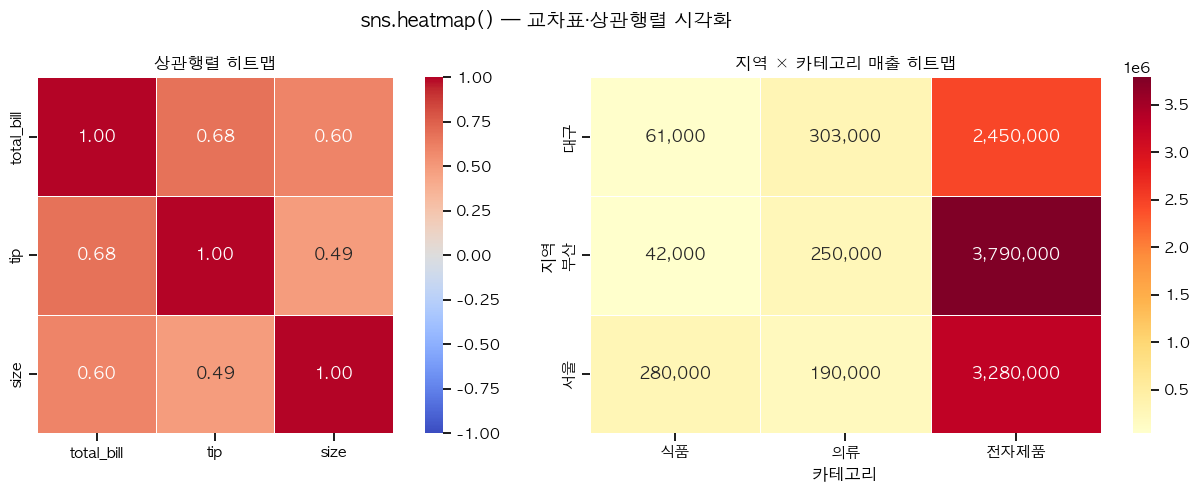

In [53]:
# heatmap: 피벗 테이블(상관행렬, 교차집계) 시각화에 최적
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 수치형 변수 상관행렬
corr = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('상관행렬 히트맵', fontsize=12, fontweight='bold')

# [오른쪽] 피벗 테이블 히트맵 (8장에서 만든 지역 × 카테고리 매출)
pivot_heat = df_sales.pivot_table(values='매출', index='지역', columns='카테고리',
                                   aggfunc='sum', fill_value=0)
sns.heatmap(pivot_heat, annot=True, fmt=',', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('지역 × 카테고리 매출 히트맵', fontsize=12, fontweight='bold')
axes[1].set_xlabel('카테고리')
axes[1].set_ylabel('지역')

plt.suptitle('sns.heatmap() — 교차표·상관행렬 시각화', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

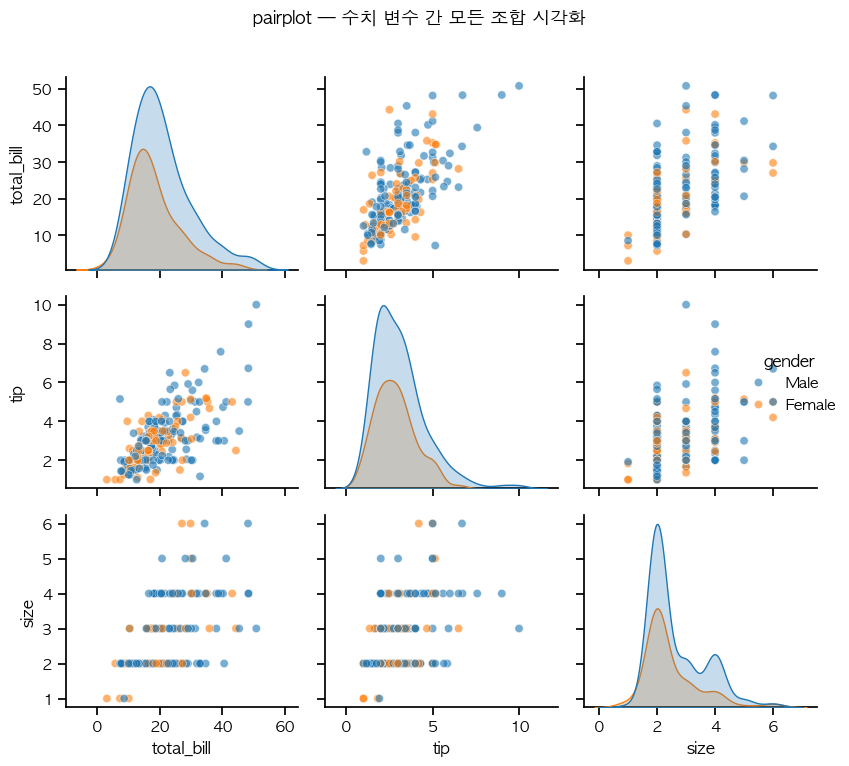

In [54]:
# pairplot: 여러 수치 변수의 모든 조합을 한번에 시각화
# (Figure-level 함수 — PairGrid 반환)
g = sns.pairplot(
    data=tips[['total_bill', 'tip', 'size']].assign(gender=tips['gender']),
    hue='gender',
    diag_kind='kde',      # 대각선: KDE (각 변수 분포)
    plot_kws={'alpha': 0.6}
)
g.figure.suptitle('pairplot — 수치 변수 간 모든 조합 시각화', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10장 핵심 정리

### Figure-level vs Axes-level 최종 비교

| | **Axes-level** | **Figure-level** |
| :--- | :--- | :--- |
| **대표 함수** | `scatterplot`, `histplot`, `boxplot`, `kdeplot`, `barplot`, `heatmap` | `relplot`, `displot`, `catplot` |
| **반환값** | `Axes` | `FacetGrid` |
| **Figure 생성** | `plt.subplots()`로 직접 생성 | 함수 내부에서 자동 생성 |
| **크기 지정** | `figsize=(w, h)` | `height=h, aspect=r` |
| **패널 분할** | 불가 | `col=`, `row=`, `col_wrap=` |
| **복합 대시보드** | 자유롭게 배치 | 독립 Figure만 가능 |
| **커스터마이징** | `ax.set_title()` 등 바로 가능 | `g.set_titles()`, `g.ax` 등 |
| **추천 상황** | 대시보드, Matplotlib 혼합 | 그룹별 자동 패널 분할 |

### 전체 함수 정리

| 카테고리 | Axes-level | Figure-level |
| :--- | :--- | :--- |
| 분포 | `histplot`, `kdeplot`, `ecdfplot`, `rugplot` | `displot` |
| 관계 | `scatterplot`, `lineplot` | `relplot` |
| 범주형 | `boxplot`, `violinplot`, `barplot`, `stripplot`, `swarmplot`, `pointplot` | `catplot` |
| 행렬 | `heatmap` | `pairplot`, `clustermap` |

<div class="alert alert-block alert-success">
<b>실무 시각화 원칙 (Seaborn 버전)</b><br>
① <b>대시보드 = Axes-level</b>: <code>plt.subplots()</code>에 <code>ax=ax</code>로 전달하여 자유롭게 배치<br>
② <b>그룹 비교 = Figure-level</b>: <code>col=</code>, <code>row=</code>로 패널 자동 분할<br>
③ <b>커스터마이징은 Matplotlib으로</b>: Seaborn으로 그리고 <code>ax.set_*()</code>으로 다듬는다<br>
④ <b>hue= 하나로 색상 자동 처리</b>: for 루프 없이 그룹별 색상을 자동 적용<br>
⑤ <b>heatmap = 피벗 테이블의 완성</b>: 8장의 <code>pivot_table()</code> 결과를 <code>sns.heatmap()</code>으로 시각화
</div>